# 03 - Walker Constellation

Third skill: constellation construction from a seed orbit or seed state.

You will learn how to:
- build Walker delta and star patterns from an NSTK `Orbit` seed
- let NSTK automatically clone supported numerical seed settings
- generate Walker `SpacecraftState` seeds for custom propagator workflows
- use `orbit_factory` when you want full control over how Walker members are built


In [8]:
# Ensure local package import when running from this examples/ folder.
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_repo_root = _cwd if (_cwd / "nstk").is_dir() else _cwd.parent
if (_repo_root / "nstk").is_dir() and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
%matplotlib widget

In [9]:
import numpy as np
from astropy.time import Time

from nstk.propagation import (
    Orbit,
    build_walker_constellation,
    build_walker_initial_states,
    spacecraft_state_from_kepler,
)
from nstk.plotting import plot_orbits
np.set_printoptions(precision=6, suppress=True)


In [10]:
# 1) Build a seed orbit
seed = Orbit.from_kepler_two_body(
    epoch=Time("2026-01-01T00:00:00", scale="utc"),
    a=7000e3,
    e=0.001,
    i=np.deg2rad(53.0),
    raan=np.deg2rad(20.0),
    argp=np.deg2rad(15.0),
    anomaly=np.deg2rad(10.0),
    anomaly_type="mean",
)

seed.propagator.getClass().getSimpleName()


'KeplerianPropagator'

delta count: 24
sat0 |r| [km], |v| [m/s]: 6993.106557116952 7553.48813380942
sat1 |r| [km], |v| [m/s]: 7001.222324395537 7544.735727289191


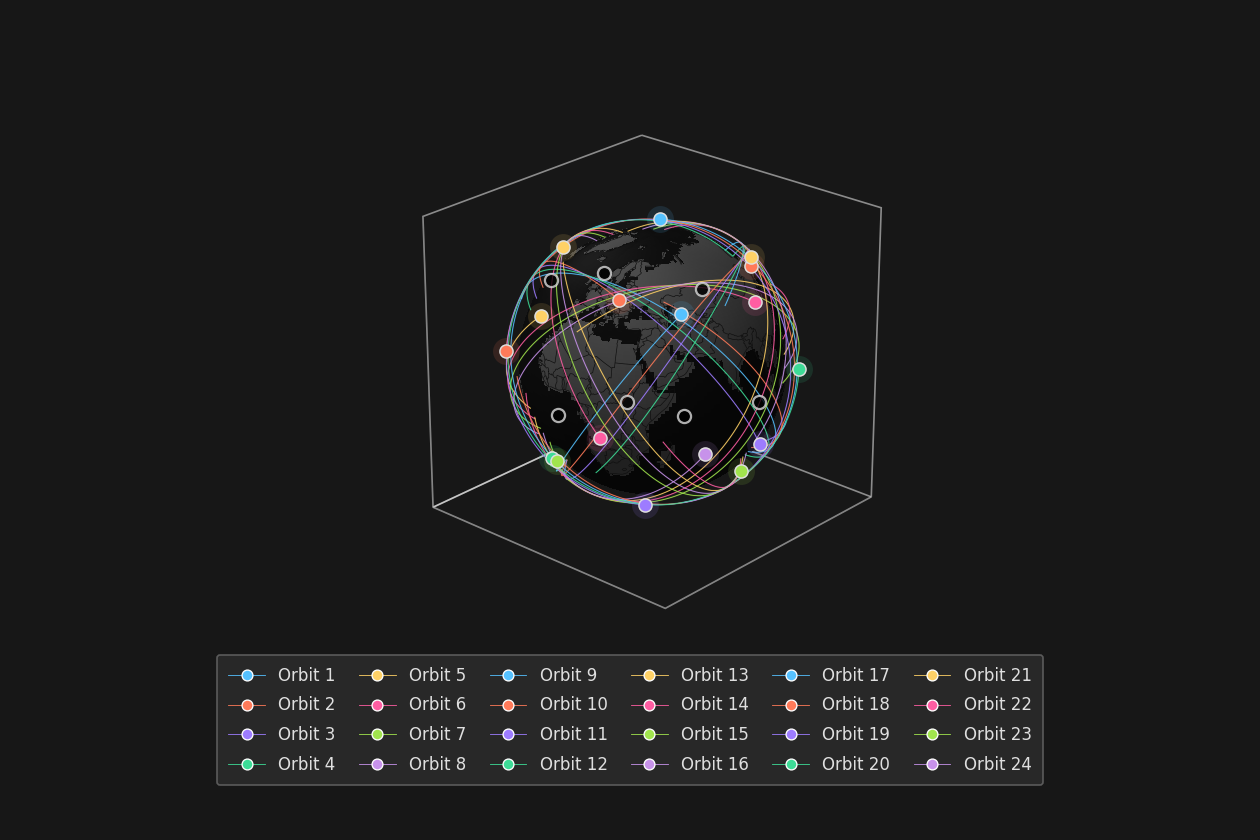

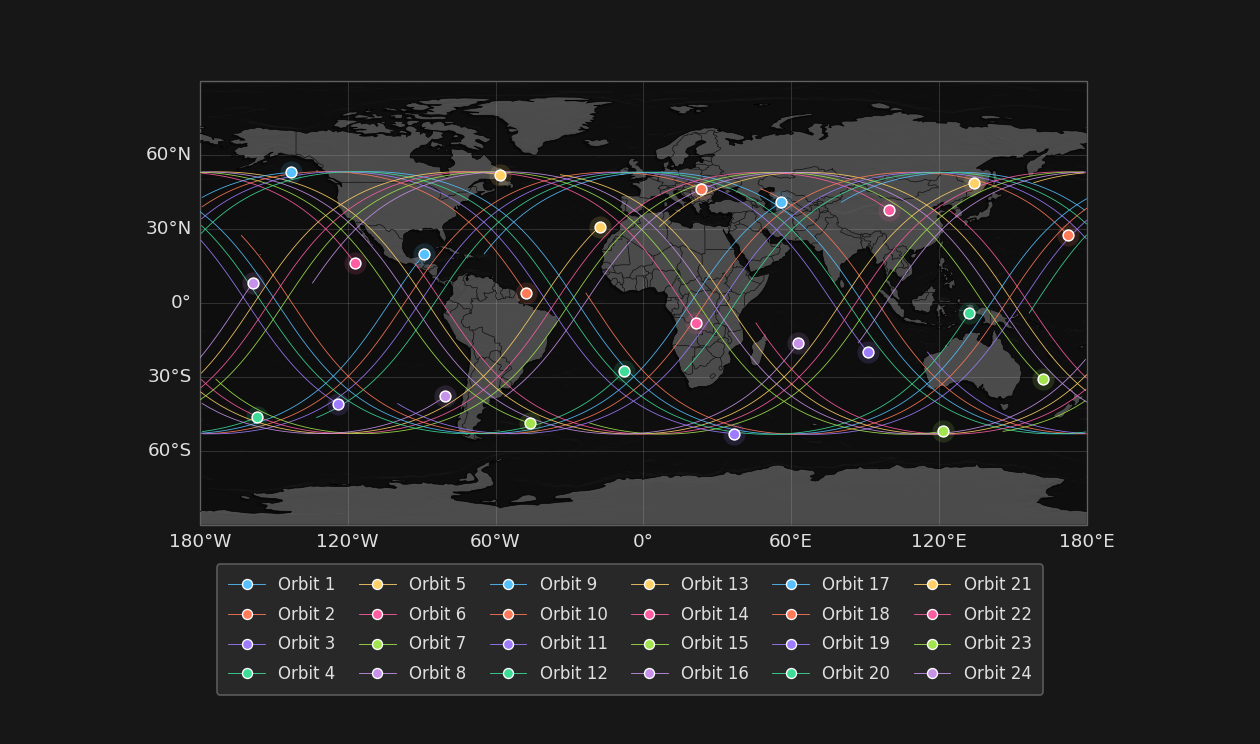

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [11]:
# 2) Walker delta: T/P/F = 24/6/1
delta = build_walker_constellation(
    seed,
    total_satellites=24,
    num_planes=6,
    phasing=1,
    pattern="delta",
    include_seed=True,
)

print("delta count:", len(delta))
r0, v0 = delta[0].get_pv(0.0, frame="native", as_quantity=False)
r1, v1 = delta[1].get_pv(0.0, frame="native", as_quantity=False)
print("sat0 |r| [km], |v| [m/s]:", np.linalg.norm(r0)/1e3, np.linalg.norm(v0))
print("sat1 |r| [km], |v| [m/s]:", np.linalg.norm(r1)/1e3, np.linalg.norm(v1))
plot_orbits(delta, view='3d', line_width=0.5)
plot_orbits(delta, view='2d', line_width=0.5)

star count: 23
last star sat |r| [km], |v| [m/s]: 6997.612043321194 7548.627961978713


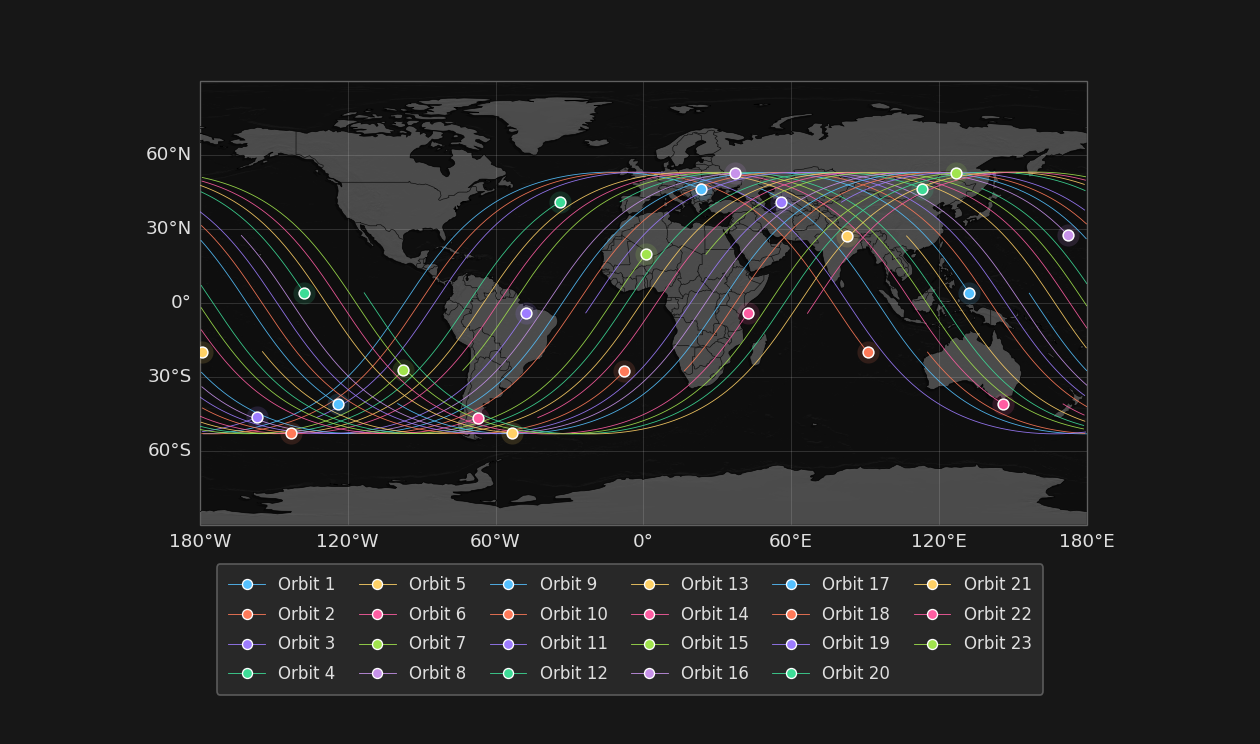

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [12]:
# 3) Walker star: T/P/F = 24/6/2
star = build_walker_constellation(
    seed,
    total_satellites=24,
    num_planes=6,
    phasing=2,
    pattern="star",
    include_seed=False,
)

print("star count:", len(star))
r_last, v_last = star[-1].get_pv(0.0, frame="native", as_quantity=False)
print("last star sat |r| [km], |v| [m/s]:", np.linalg.norm(r_last)/1e3, np.linalg.norm(v_last))
plot_orbits(star, view='2d', line_width=0.5)


numerical walker count: 12
first propagator class: NumericalPropagator
first force-model count: 2


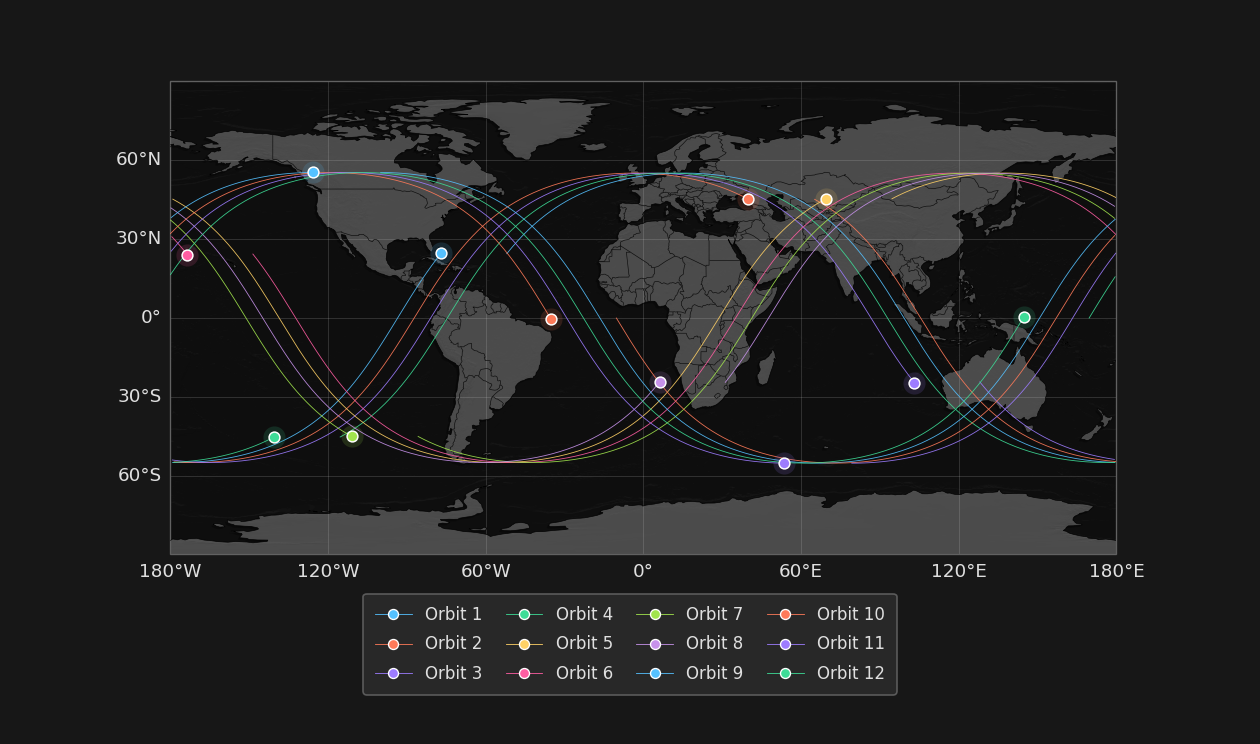

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [13]:
# 4) Numerical Walker from a numerical seed
seed_num = Orbit.from_kepler_numerical(
    epoch=Time("2026-01-01T00:00:00", scale="utc"),
    a=7100e3,
    e=0.002,
    i=np.deg2rad(55.0),
    raan=np.deg2rad(30.0),
    argp=np.deg2rad(25.0),
    anomaly=np.deg2rad(5.0),
    anomaly_type="mean",
    gravity_degree=8,
    gravity_order=8,
    enable_drag=False,
    enable_third_body=False,
    enable_srp=False,
)

walker_num = build_walker_constellation(
    seed_num,
    total_satellites=12,
    num_planes=3,
    phasing=1,
    pattern="delta",
    include_seed=True,
)

print("numerical walker count:", len(walker_num))
print("first propagator class:", walker_num[0].propagator.getClass().getSimpleName())
print("first force-model count:", walker_num[0].propagator.getAllForceModels().size())
plot_orbits(walker_num, view='2d', line_width=0.5)


walker state count: 6
seed-state mass [kg]: 275.0
custom walker count: 6
custom walker propagator: KeplerianPropagator


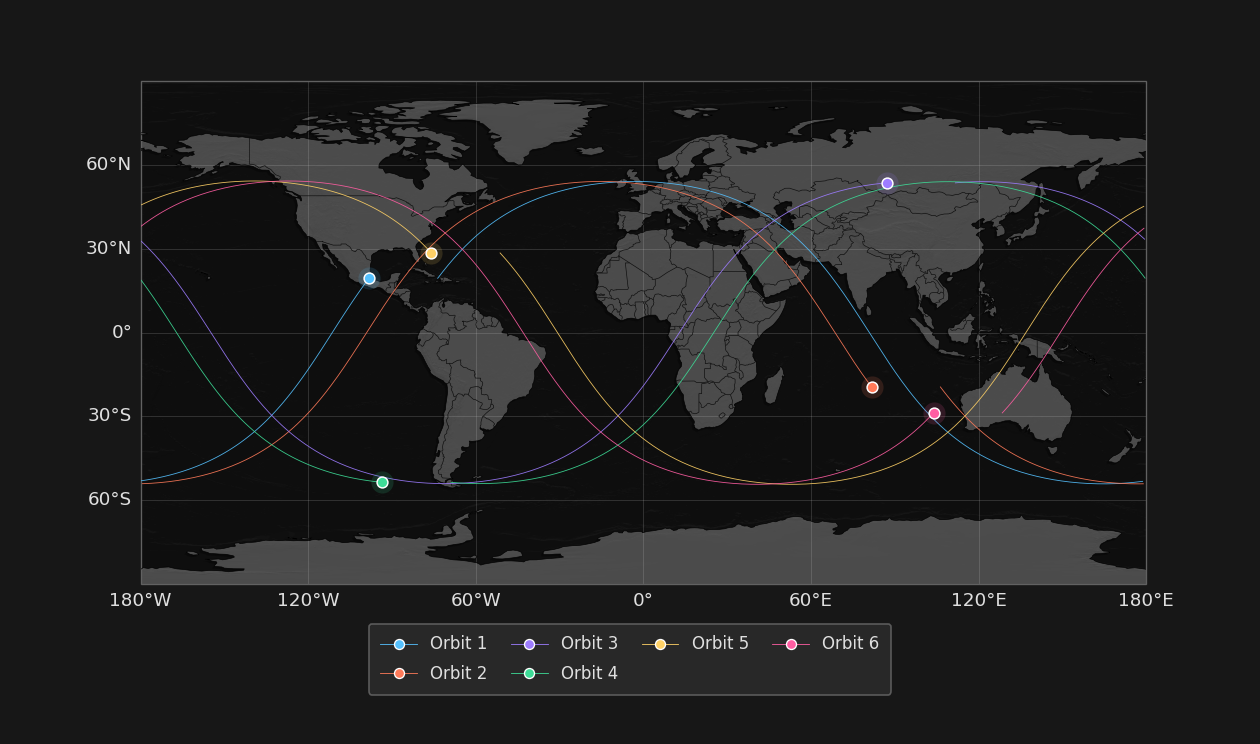

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [14]:
# 5) Advanced path: seed SpacecraftState + custom orbit_factory
seed_state = spacecraft_state_from_kepler(
    epoch=Time("2026-01-01T00:00:00", scale="utc"),
    a=7050e3,
    e=0.0015,
    i=np.deg2rad(54.0),
    raan=np.deg2rad(12.0),
    argp=np.deg2rad(18.0),
    anomaly=np.deg2rad(6.0),
    anomaly_type="mean",
    mass=275.0,
    attitude="tnw",
)

walker_states = build_walker_initial_states(
    seed_state,
    total_satellites=6,
    num_planes=3,
    phasing=1,
    pattern="delta",
    include_seed=True,
)

def custom_orbit_factory(state):
    # Replace this with your own propagator construction when needed.
    return Orbit.from_spacecraft_state(state)

custom_walker = build_walker_constellation(
    seed_state,
    total_satellites=6,
    num_planes=3,
    phasing=1,
    pattern="delta",
    include_seed=True,
    orbit_factory=custom_orbit_factory,
)

print("walker state count:", len(walker_states))
print("seed-state mass [kg]:", float(walker_states[0].getMass()))
print("custom walker count:", len(custom_walker))
print("custom walker propagator:", custom_walker[0].propagator.getClass().getSimpleName())
plot_orbits(custom_walker, view='2d', line_width=0.5)


Next notebook: **04 - Interval Coverage**.
